<a href="https://colab.research.google.com/github/swirita/Chicago-Crime-Analysis-and-Forecasting/blob/main/notebooks/02_crime_analysis_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chicago Crime Analysis
- Author: Siwar Ehwass

## Overview

This notebook analyzes Chicago crime data to answer three questions:

1. How has the total number of crimes changed across the years?
2. How do crimes compare during AM and PM rush hours?
3. Which holidays have the most reported crimes?
4. Check Seasonality

## Imports

In [15]:
%pip install -q holidays

from pathlib import Path

import holidays
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

## Custom Functions

In [16]:
# visual style
COLORS = {
    "main": "#243B53",
    "secondary": "#5B8DB8",
    "warning": "#E9A23B",
    "background": "#F7F8FA",
    "text": "#263238",
}

plt.rcParams.update({
    "figure.figsize": (16, 5),
    "figure.dpi": 120,
    "figure.facecolor": COLORS["background"],
    "axes.facecolor": COLORS["background"],
    "font.size": 11,
})


def style_chart(ax, title, xlabel="", ylabel=""):
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    ax.set_title(
        title,
        loc="left",
        fontsize=15,
        fontweight="bold",
        color=COLORS["text"],
        pad=15
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

In [17]:
# Print the cycle length, minimum, maximum, and magnitude.
def print_cycle_summary(cycle, cycle_length, unit):
    minimum = cycle.min()
    maximum = cycle.max()
    magnitude = maximum - minimum

    print(f"Cycle length: {cycle_length}")
    print(
        f"Minimum seasonal effect: {minimum:,.1f} {unit} "
        f"({cycle.idxmin()})"
    )
    print(
        f"Maximum seasonal effect: {maximum:,.1f} {unit} "
        f"({cycle.idxmax()})"
    )
    print(f"Cycle magnitude: {magnitude:,.1f} {unit}")

In [18]:
# Plot one complete seasonal cycle as a line plot.
def plot_seasonal_cycle(
    cycle,
    repeat_label,
    title,
    xlabel,
    ylabel,
    color,
    rotation=0
):

    # Repeat the first value to visually close the cycle
    labels = list(cycle.index) + [repeat_label]
    values = cycle.tolist() + [cycle.iloc[0]]

    positions = np.arange(len(labels))

    fig, ax = plt.subplots(figsize=(11, 5))

    ax.plot(
        positions,
        values,
        color=color,
        marker="o",
        markersize=7,
        linewidth=2.5
    )

    # Zero means no seasonal effect
    ax.axhline(
        0,
        color=COLORS["text"],
        linewidth=1
    )

    # Label only the minimum and maximum points
    minimum_position = int(np.argmin(cycle.values))
    maximum_position = int(np.argmax(cycle.values))

    for position in [minimum_position, maximum_position]:
        value = cycle.iloc[position]

        ax.annotate(
            f"{value:+,.1f}",
            xy=(position, value),
            xytext=(0, 12),
            textcoords="offset points",
            ha="center",
            bbox={
                "facecolor": COLORS["background"],
                "edgecolor": "none",
                "pad": 1.5
            }
        )

    ax.set_xticks(positions)
    ax.set_xticklabels(
        labels,
        rotation=rotation,
        ha="right" if rotation else "center"
    )

    # Add space around the annotations
    ax.margins(x=0.02, y=0.20)

    style_chart(
        ax,
        title=title,
        xlabel=xlabel,
        ylabel=ylabel
    )

    plt.tight_layout()
    plt.show()

## Load & Prepare Data

In [19]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
DATA_FOLDER = Path(
    "/content/drive/MyDrive/Chicago-Crime-Analysis-and-Forecasting/data/raw"
)

crime_files = sorted(DATA_FOLDER.glob("Chicago-Crime_*.csv"))

if not crime_files:
    raise FileNotFoundError(
        f"No crime CSV files were found in {DATA_FOLDER}. Check the folder path."
    )

print(f"Found {len(crime_files)} files.")


Found 26 files.


In [21]:
def load_crime_file(file_path):
    # Load the needed columns and prepare the Date column.
    data = pd.read_csv(
        file_path,
        usecols=["ID", "Date", "Primary Type"],
        low_memory=False,
    )

    data["Date"] = pd.to_datetime(
        data["Date"],
        format="%m/%d/%Y %I:%M:%S %p",
        errors="coerce",
    )

    return data.dropna(subset=["Date"])


df = pd.concat(
    [load_crime_file(file_path) for file_path in crime_files],
    ignore_index=True,
)

rows_before_cleaning = len(df)
df = df.drop_duplicates(subset="ID").dropna(subset=["Primary Type"])
df = df.sort_values("Date").set_index("Date")

print(f"Removed {rows_before_cleaning - len(df):,} duplicate or incomplete rows.")
df.head()


Removed 0 duplicate or incomplete rows.


,ID,Primary Type
Date,,
2001-01-01,8146039,CRIM SEXUAL ASSAULT
2001-01-01,6884455,CRIM SEXUAL ASSAULT
2001-01-01,6835516,SEX OFFENSE
2001-01-01,6742268,OFFENSE INVOLVING CHILDREN
2001-01-01,6739668,THEFT


In [22]:
print(f"Rows: {len(df):,}")
print(f"Date range: {df.index.min():%Y-%m-%d} to {df.index.max():%Y-%m-%d}")
print(f"Duplicate IDs: {df['ID'].duplicated().sum():,}")
print(f"Missing crime types: {df['Primary Type'].isna().sum():,}")


Rows: 8,627,693
Date range: 2001-01-01 to 2026-08-25
Duplicate IDs: 0
Missing crime types: 0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8627693 entries, 2001-01-01 00:00:00 to 2026-08-25 00:00:00
Data columns (total 2 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   ID            int64 
 1   Primary Type  object
dtypes: int64(1), object(1)
memory usage: 197.5+ MB


## Feature Engineering: US Holidays

In [24]:
us_holidays = holidays.country_holidays("US")
df["US Holiday"] = [us_holidays.get(date) for date in df.index.date]

print(f"Crimes reported on holidays: {df['US Holiday'].notna().sum():,}")
df.head()


Crimes reported on holidays: 256,490


,ID,Primary Type,US Holiday
Date,,,
2001-01-01,8146039,CRIM SEXUAL ASSAULT,New Year's Day
2001-01-01,6884455,CRIM SEXUAL ASSAULT,New Year's Day
2001-01-01,6835516,SEX OFFENSE,New Year's Day
2001-01-01,6742268,OFFENSE INVOLVING CHILDREN,New Year's Day
2001-01-01,6739668,THEFT,New Year's Day


## 1. Crimes Across the Years

- Is the total number of crimes increasing or decreasing across the years?
- Are there any individual crimes that are doing the opposite (e.g., decreasing when overall crime is increasing or vice-versa)?

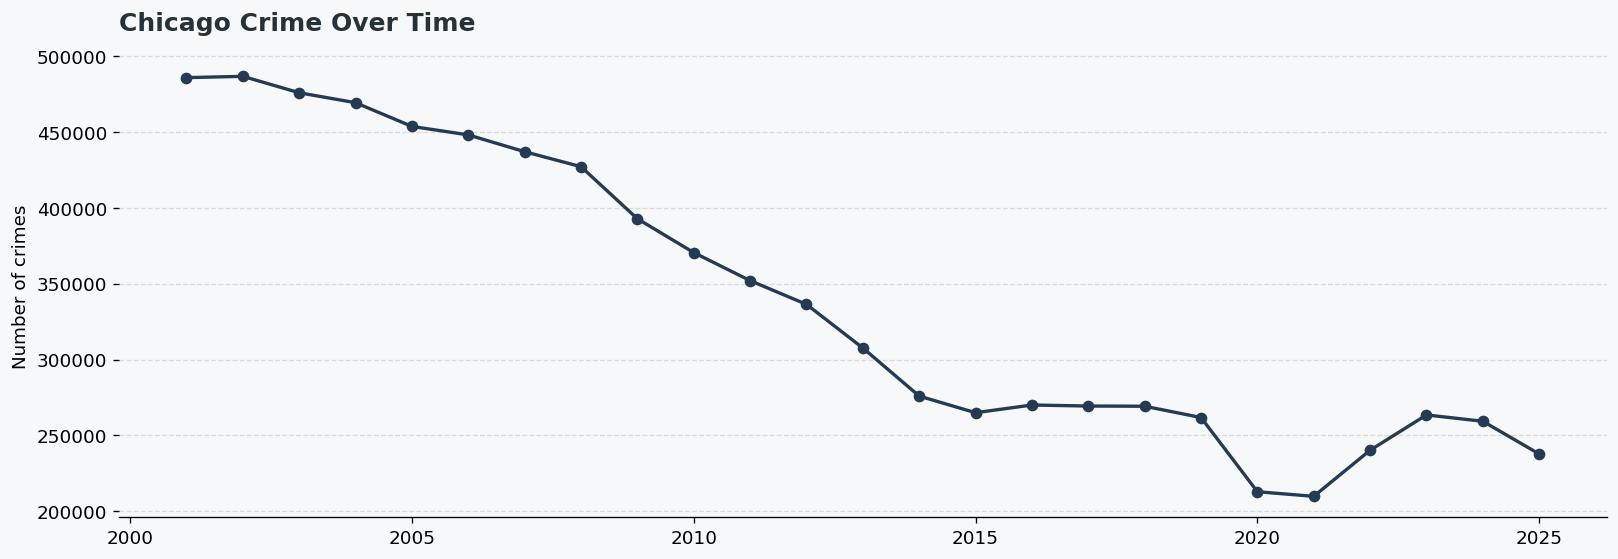

From 2001 to 2025, total crime decreased by 51.1% (485,974 to 237,695).


In [25]:
annual_counts = df.resample("YS").size()
annual_counts.index = annual_counts.index.year
annual_counts.name = "Number of Crimes"

# Remove the latest year when the data does not reach December 31.
latest_date = df.index.max()
end_of_latest_year = pd.Timestamp(latest_date.year, 12, 31)
if latest_date.normalize() < end_of_latest_year:
    annual_counts = annual_counts.iloc[:-1]

fig, ax = plt.subplots()
ax.plot(
    annual_counts.index,
    annual_counts.values,
    marker="o",
    color=COLORS["main"],
    linewidth=2,
)
style_chart(ax, "Chicago Crime Over Time", ylabel="Number of crimes")
plt.show()

first_year = annual_counts.index.min()
last_year = annual_counts.index.max()
first_count = annual_counts.loc[first_year]
last_count = annual_counts.loc[last_year]
change_percent = (last_count - first_count) / first_count * 100

if change_percent > 0:
    direction = "increased"
elif change_percent < 0:
    direction = "decreased"
else:
    direction = "did not change"

if direction == "did not change":
    print(f"Total crime was the same in {first_year} and {last_year}: {first_count:,} crimes.")
else:
    print(
        f"From {first_year} to {last_year}, total crime {direction} "
        f"by {abs(change_percent):.1f}% ({first_count:,} to {last_count:,})."
    )


11 crime types moved opposite to the overall change:
['CONCEALED CARRY LICENSE VIOLATION', 'CRIMINAL SEXUAL ASSAULT', 'DECEPTIVE PRACTICE', 'HUMAN TRAFFICKING', 'INTERFERENCE WITH PUBLIC OFFICER', 'NON-CRIMINAL', 'OBSCENITY', 'OTHER NARCOTIC VIOLATION', 'PUBLIC INDECENCY', 'STALKING', 'WEAPONS VIOLATION']


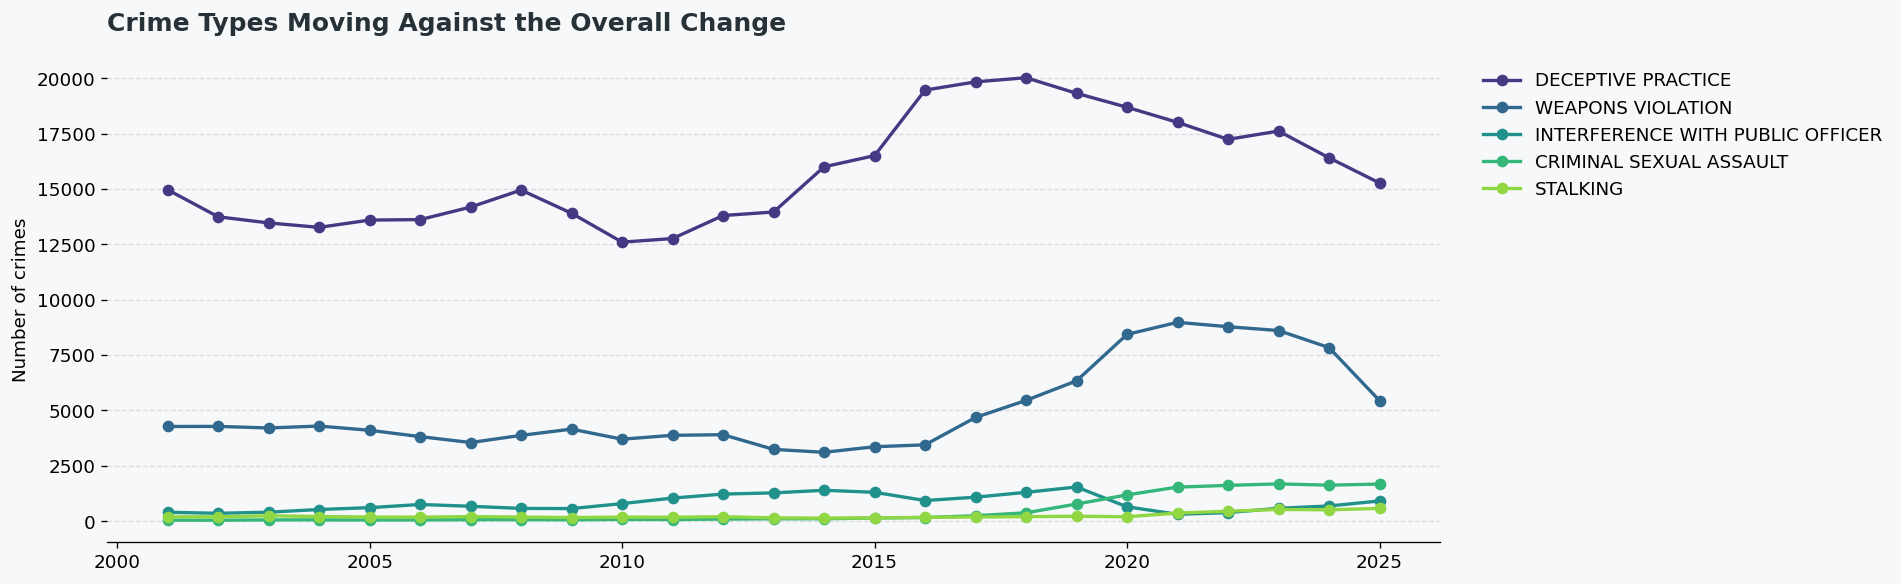

In [26]:
RANK_COLORS = sns.color_palette("viridis", n_colors=5)

complete_years_df = df[df.index.year <= last_year]

counts_by_type = (
    complete_years_df
    .groupby([complete_years_df.index.year, "Primary Type"])
    .size()
    .unstack(fill_value=0)
)

first_counts = counts_by_type.loc[first_year]
last_counts = counts_by_type.loc[last_year]

if direction == "decreased":
    opposite_types = last_counts[last_counts > first_counts].index
elif direction == "increased":
    opposite_types = last_counts[last_counts < first_counts].index
else:
    opposite_types = pd.Index([])

print(f"{len(opposite_types)} crime types moved opposite to the overall change:")
print(opposite_types.tolist())

# Plot the five largest opposite-moving crime types across all years.
top_opposite = (
    counts_by_type[opposite_types]
    .sum()
    .nlargest(5)
    .index
)

fig, ax = plt.subplots()
for crime_type, color in zip(top_opposite, RANK_COLORS):
    ax.plot(
        counts_by_type.index,
        counts_by_type[crime_type],
        marker="o",
        label=crime_type,
        color=color,
        linewidth=2,
    )

style_chart(ax, "Crime Types Moving Against the Overall Change", ylabel="Number of crimes")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

## 2. Comparing AM vs. PM Rush Hour:
- Are crimes more common during AM rush hour or PM rush hour?
- consider any crime that occurred between 7 AM - 10 AM as AM rush hour
, any crime that occurred between 4 - 7 PM as PM rush hour.

- What are the top 5 most common crimes during AM rush hour? What are the top 5 most common crimes during PM rush hour?

- Are Motor Vehicle Thefts more common during AM rush hour or PM Rush Hour?

Rush Hour
AM Rush Hour     863343
PM Rush Hour    1352388
Name: count, dtype: int64

PM Rush Hour has more reported crimes.


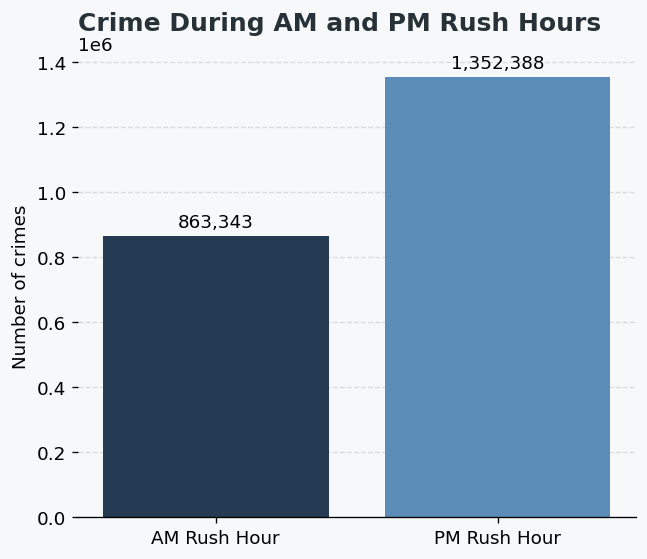

In [28]:
AM_COLOR = COLORS["main"]
PM_COLOR = COLORS["secondary"]

hours = df.index.hour
am_mask = (hours >= 7) & (hours < 10)
pm_mask = (hours >= 16) & (hours < 19)
rush_mask = am_mask | pm_mask

rush_df = df.loc[rush_mask, ["Primary Type"]].copy()
rush_df["Rush Hour"] = np.where(am_mask[rush_mask], "AM Rush Hour", "PM Rush Hour")

rush_order = ["AM Rush Hour", "PM Rush Hour"]
rush_totals = rush_df["Rush Hour"].value_counts().reindex(rush_order, fill_value=0)

print(rush_totals)
if rush_totals.nunique() == 1:
    print("\nAM and PM rush hours have the same number of reported crimes.")
else:
    print(f"\n{rush_totals.idxmax()} has more reported crimes.")

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(rush_totals.index, rush_totals.values, color=[AM_COLOR, PM_COLOR])
ax.bar_label(bars, labels=[f"{value:,}" for value in rush_totals.values], padding=3)
style_chart(ax, "Crime During AM and PM Rush Hours", ylabel="Number of crimes")
plt.show()


Top 5 crimes during AM Rush Hour:
Primary Type
THEFT              206607
BATTERY            123474
CRIMINAL DAMAGE     91156
BURGLARY            77427
OTHER OFFENSE       69818
Name: count, dtype: int64

Top 5 crimes during PM Rush Hour:
Primary Type
THEFT              331085
BATTERY            237998
CRIMINAL DAMAGE    148549
NARCOTICS          107217
ASSAULT            104249
Name: count, dtype: int64


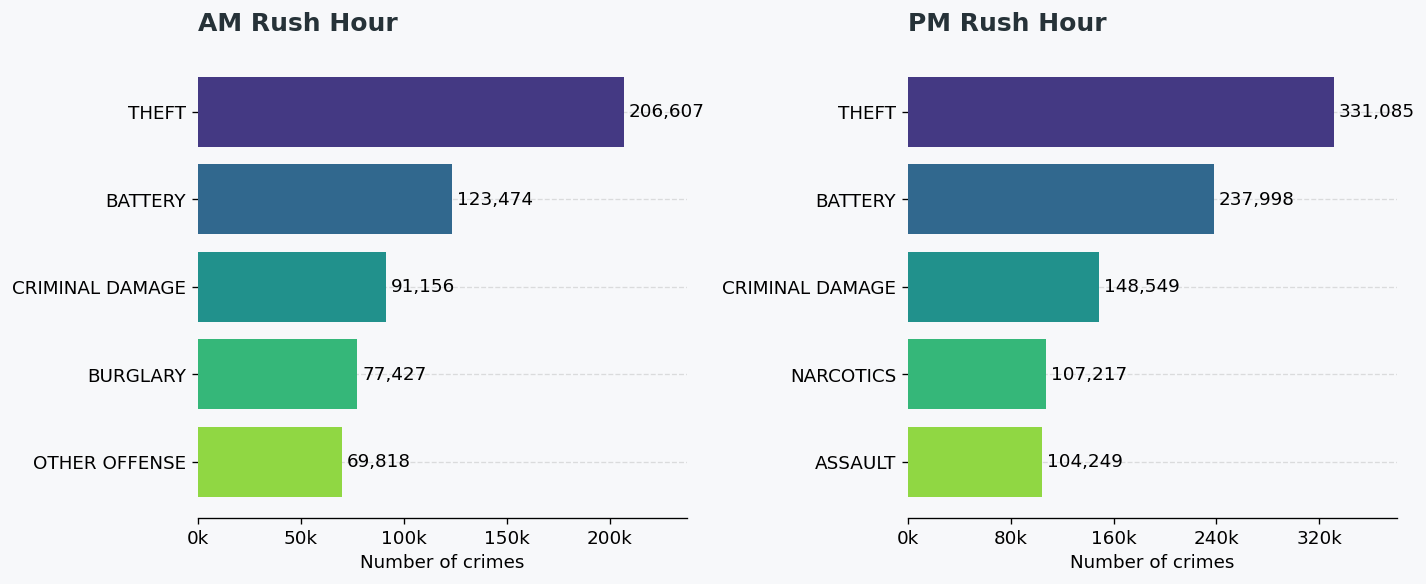

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, period in zip(axes, rush_order):
    top_five = (
        rush_df.loc[rush_df["Rush Hour"] == period, "Primary Type"]
        .value_counts()
        .head(5)
        .sort_values()
    )

    print(f"\nTop 5 crimes during {period}:")
    print(top_five.sort_values(ascending=False))

    bars = ax.barh(top_five.index, top_five.values, color=RANK_COLORS[::-1])
    ax.bar_label(bars, labels=[f"{value:,}" for value in top_five.values], padding=3)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(5))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x / 1000:,.0f}k"))
    ax.margins(x=0.15)
    style_chart(ax, period, xlabel="Number of crimes")

plt.tight_layout()
plt.show()

Rush Hour
AM Rush Hour    48951
PM Rush Hour    66420
Name: count, dtype: int64

Motor vehicle theft is more common during PM Rush Hour.


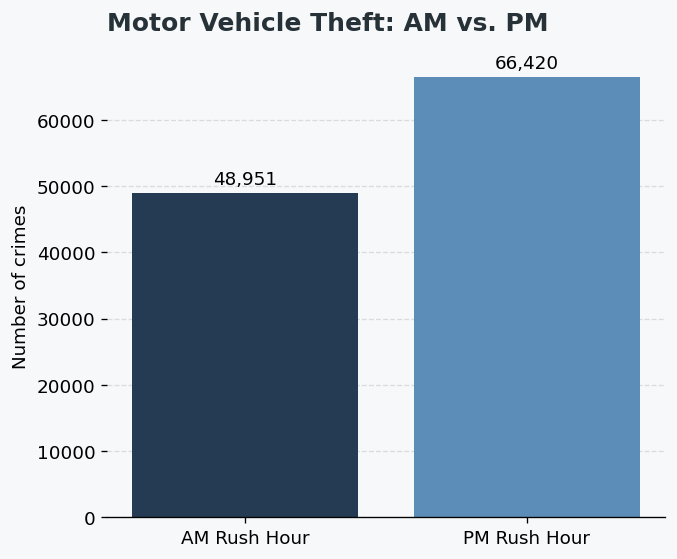

In [30]:
motor_vehicle_thefts = (
    rush_df.loc[rush_df["Primary Type"] == "MOTOR VEHICLE THEFT", "Rush Hour"]
    .value_counts()
    .reindex(rush_order, fill_value=0)
)

print(motor_vehicle_thefts)
if motor_vehicle_thefts.nunique() == 1:
    print("\nMotor vehicle theft is equally common during AM and PM rush hours.")
else:
    print(f"\nMotor vehicle theft is more common during {motor_vehicle_thefts.idxmax()}.")

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(
    motor_vehicle_thefts.index,
    motor_vehicle_thefts.values,
    color=[AM_COLOR, PM_COLOR],
)
ax.bar_label(bars, labels=[f"{value:,}" for value in motor_vehicle_thefts.values], padding=3)
style_chart(ax, "Motor Vehicle Theft: AM vs. PM", ylabel="Number of crimes")
plt.show()


## 3. Comparing Holidays

- What are the top 3 holidays with the largest number of crimes?

-  For each of the top 3 holidays with the most crime, what are the top 5 most common crimes on that holiday?

Top 3 holidays by number of reported crimes:
US Holiday
New Year's Day      37240
Independence Day    25755
Labor Day           24506
Name: count, dtype: int64


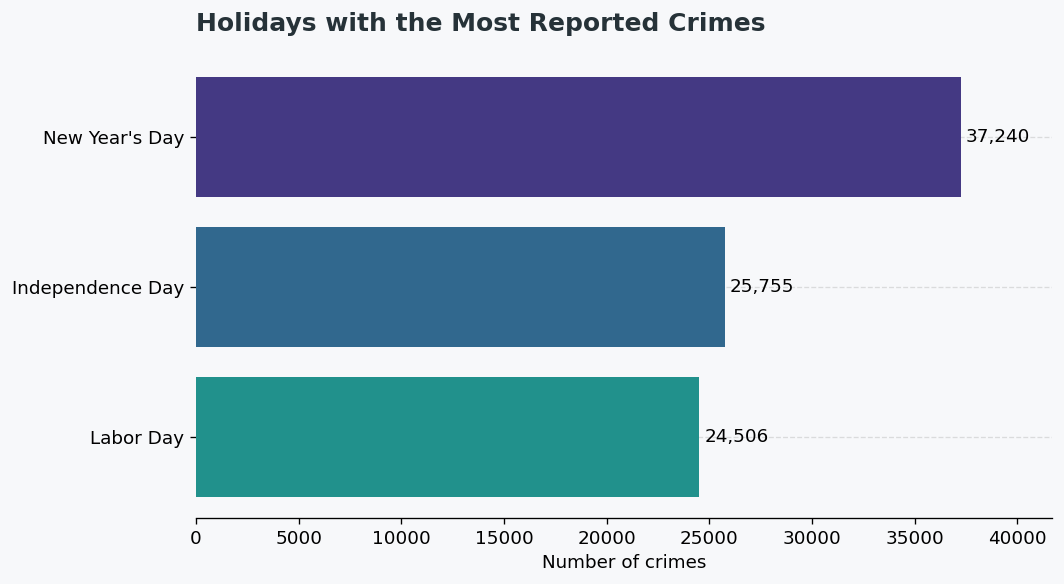

In [32]:
holiday_df = df[df["US Holiday"].notna()]
top_holidays = holiday_df["US Holiday"].value_counts().head(3)

print("Top 3 holidays by number of reported crimes:")
print(top_holidays)

fig, ax = plt.subplots(figsize=(9, 5))
plot_data = top_holidays.sort_values()
bars = ax.barh(plot_data.index, plot_data.values, color=RANK_COLORS[:3][::-1])
ax.bar_label(bars, labels=[f"{value:,}" for value in plot_data.values], padding=3)
ax.margins(x=0.12)
style_chart(ax, "Holidays with the Most Reported Crimes", xlabel="Number of crimes")
plt.tight_layout()
plt.show()


Top 5 crimes on New Year's Day:
Primary Type
THEFT                 7334
BATTERY               6883
CRIMINAL DAMAGE       3782
DECEPTIVE PRACTICE    3706
OTHER OFFENSE         2676
Name: count, dtype: int64

Top 5 crimes on Independence Day:
Primary Type
BATTERY            6495
THEFT              4618
CRIMINAL DAMAGE    3752
ASSAULT            1824
NARCOTICS          1590
Name: count, dtype: int64

Top 5 crimes on Labor Day:
Primary Type
BATTERY            5061
THEFT              4989
CRIMINAL DAMAGE    2768
NARCOTICS          2130
ASSAULT            1730
Name: count, dtype: int64


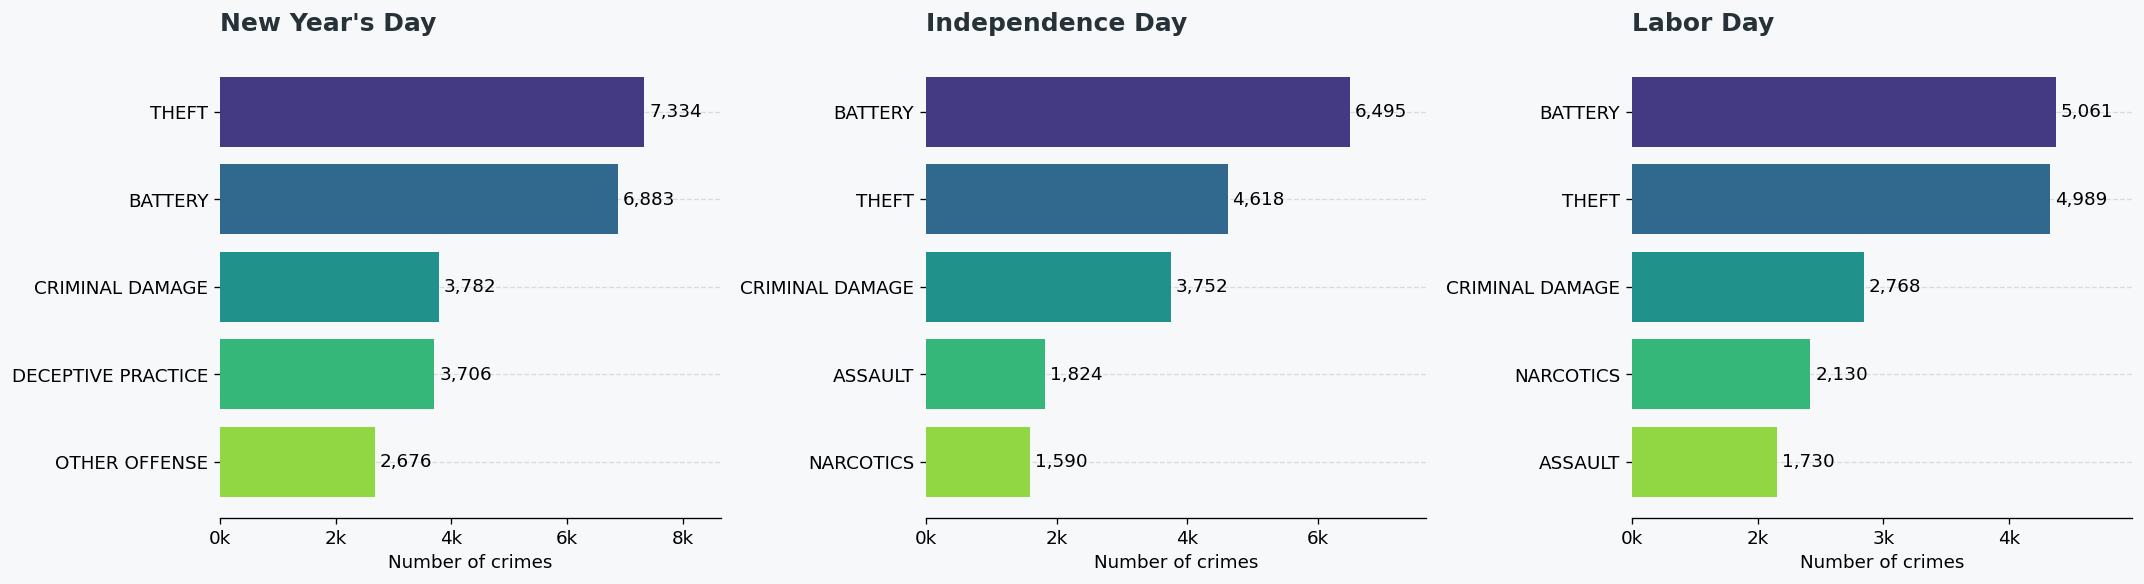

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, holiday_name in zip(axes, top_holidays.index):
    top_five = (
        holiday_df.loc[holiday_df["US Holiday"] == holiday_name, "Primary Type"]
        .value_counts()
        .head(5)
        .sort_values()
    )

    print(f"\nTop 5 crimes on {holiday_name}:")
    print(top_five.sort_values(ascending=False))

    bars = ax.barh(top_five.index, top_five.values, color=RANK_COLORS[::-1])
    ax.bar_label(bars, labels=[f"{value:,}" for value in top_five.values], padding=3)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(5))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x / 1000:,.0f}k"))
    ax.margins(x=0.18)
    style_chart(ax, holiday_name, xlabel="Number of crimes")

plt.tight_layout()
plt.show()

## 4. Crime Cycles (Seasonality)

This section uses `seasonal_decompose()` to study three focused patterns:

1. A weekly cycle in daily total crime (`period=7`)
2. A yearly cycle in monthly total crime (`period=12`)
3. A yearly cycle in monthly Motor Vehicle Theft (`period=12`)

The most recent ten complete years are used. This gives each decomposition enough repeated cycles while keeping the results relevant to recent crime patterns.

The decomposition uses an **additive model**. Therefore, the seasonal values represent crimes above or below the underlying trend. Cycle magnitude is calculated as the maximum seasonal effect minus the minimum seasonal effect.


In [35]:
# Keep the most recent 10 complete years.
season_start_year = max(df.index.min().year, last_year - 9)
season_df = df.loc[f"{season_start_year}-01-01":f"{last_year}-12-31"]

print(f"Seasonality period selected: {season_start_year} to {last_year}")
print(f"Number of crimes selected: {len(season_df):,}")


Seasonality period selected: 2016 to 2025
Number of crimes selected: 2,493,360


### 4.1 Weekly Cycle in Total Crime

The data is resampled by day. A period of 7 checks whether the pattern repeats every seven days.


Cycle length: 7 days
Minimum seasonal effect: -11.7 crimes (Thursday)
Maximum seasonal effect: 25.3 crimes (Friday)
Cycle magnitude: 37.0 crimes


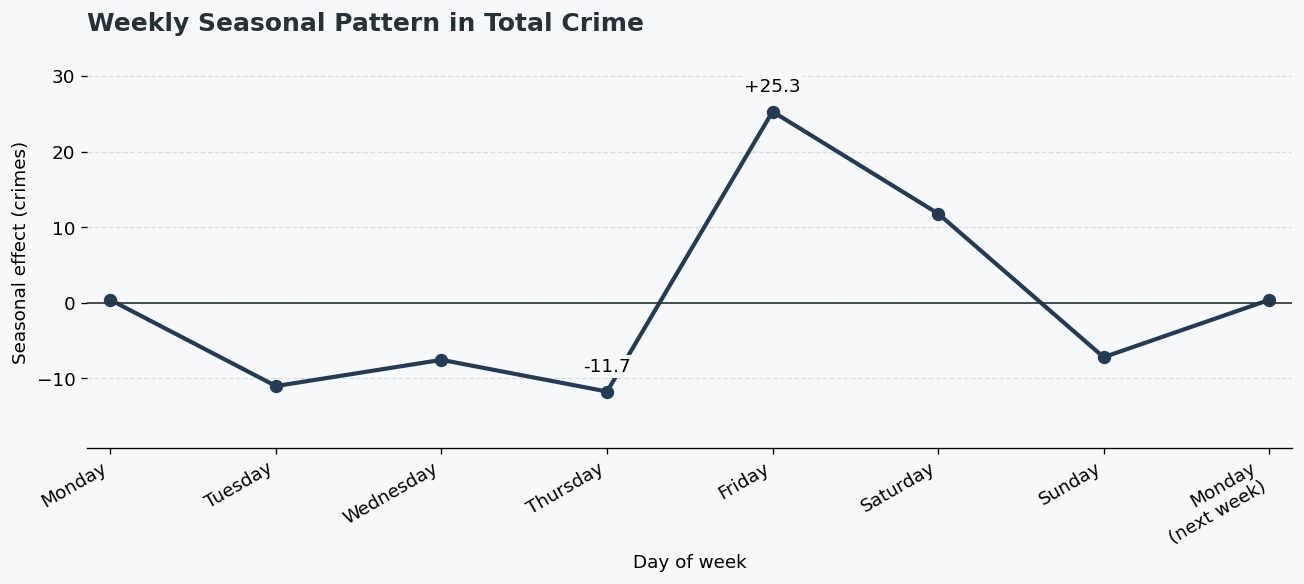

In [36]:
# Count the total crimes for each day
daily_crimes = season_df.resample("D").size()

# Look for a pattern that repeats every 7 days
daily_decomposition = seasonal_decompose(
    daily_crimes,
    model="additive",
    period=7
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Find the average seasonal effect for each weekday
daily_cycle = (
    daily_decomposition.seasonal
    .groupby(
        daily_decomposition.seasonal.index.day_name()
    )
    .mean()
    .reindex(day_order)
)

print_cycle_summary(
    cycle=daily_cycle,
    cycle_length="7 days",
    unit="crimes"
)

plot_seasonal_cycle(
    cycle=daily_cycle,
    repeat_label="Monday\n(next week)",
    title="Weekly Seasonal Pattern in Total Crime",
    xlabel="Day of week",
    ylabel="Seasonal effect (crimes)",
    color=COLORS["main"],
    rotation=30
)

### 4.2 Yearly Cycle in Total Crime

The data is resampled by month. A period of 12 checks whether the pattern repeats every twelve months.


Cycle length: 12 months
Minimum seasonal effect: -3,291.6 crimes (Feb)
Maximum seasonal effect: 2,400.3 crimes (Jul)
Cycle magnitude: 5,691.9 crimes


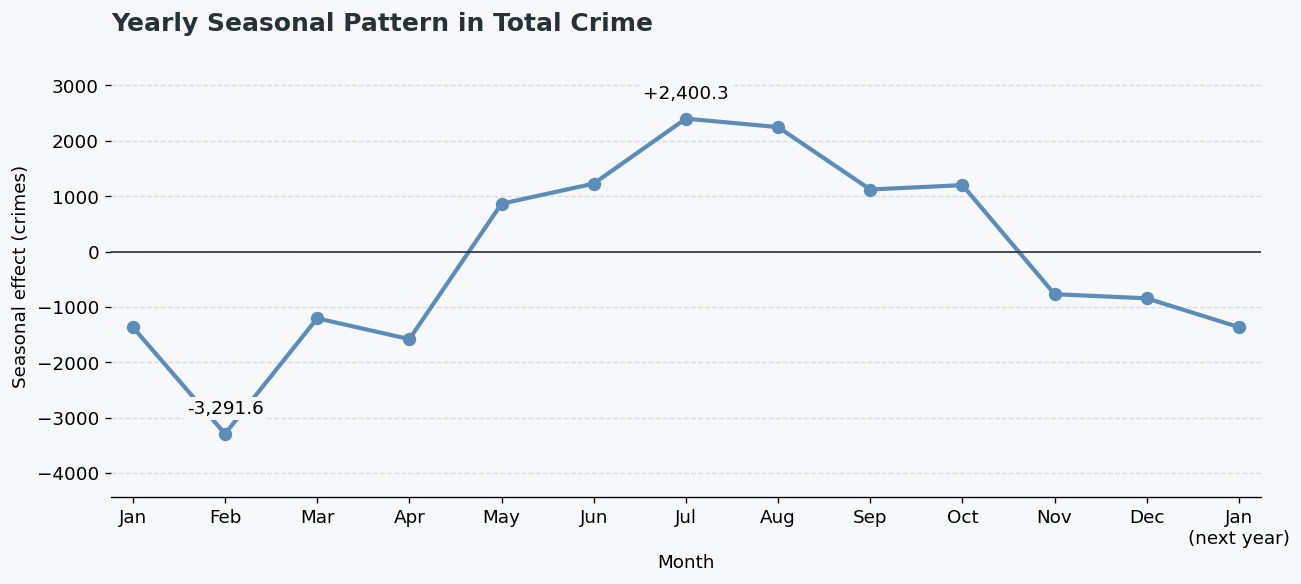

In [37]:
# Count the total crimes for each month
monthly_crimes = season_df.resample("MS").size()

# Look for a pattern that repeats every 12 months
monthly_decomposition = seasonal_decompose(
    monthly_crimes,
    model="additive",
    period=12
)

month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

# Find the average seasonal effect for each month
monthly_cycle = (
    monthly_decomposition.seasonal
    .groupby(
        monthly_decomposition.seasonal.index.month
    )
    .mean()
)

monthly_cycle.index = month_names

print_cycle_summary(
    cycle=monthly_cycle,
    cycle_length="12 months",
    unit="crimes"
)

plot_seasonal_cycle(
    cycle=monthly_cycle,
    repeat_label="Jan\n(next year)",
    title="Yearly Seasonal Pattern in Total Crime",
    xlabel="Month",
    ylabel="Seasonal effect (crimes)",
    color=COLORS["secondary"]
)

### 4.3 Yearly Cycle in Motor Vehicle Theft

Motor Vehicle Theft is analyzed separately because it was already a crime type of interest in the rush-hour analysis.


Cycle length: 12 months
Minimum seasonal effect: -214.3 thefts (Feb)
Maximum seasonal effect: 205.0 thefts (Oct)
Cycle magnitude: 419.3 thefts


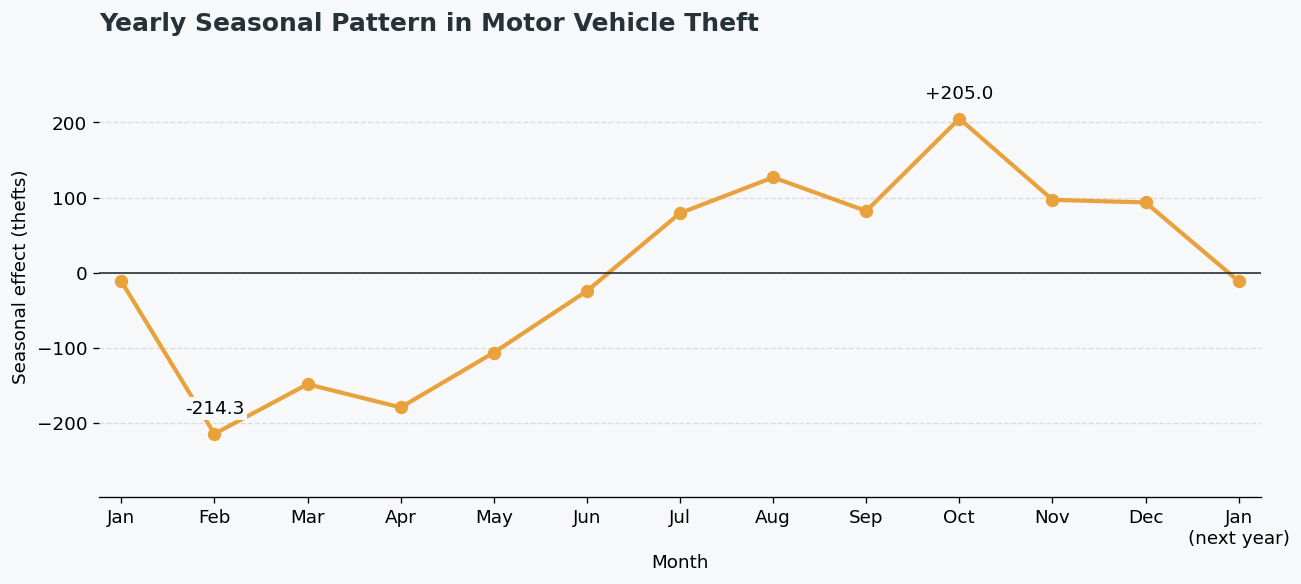

In [38]:
# True means the crime is Motor Vehicle Theft
is_motor_vehicle_theft = (
    season_df["Primary Type"]
    == "MOTOR VEHICLE THEFT"
)

# Count Motor Vehicle Thefts for each month
monthly_motor_vehicle_thefts = (
    is_motor_vehicle_theft
    .resample("MS")
    .sum()
)

# Look for a pattern that repeats every 12 months
motor_vehicle_decomposition = seasonal_decompose(
    monthly_motor_vehicle_thefts,
    model="additive",
    period=12
)

# Find the average seasonal effect for each month
motor_vehicle_cycle = (
    motor_vehicle_decomposition.seasonal
    .groupby(
        motor_vehicle_decomposition.seasonal.index.month
    )
    .mean()
)

motor_vehicle_cycle.index = month_names

print_cycle_summary(
    cycle=motor_vehicle_cycle,
    cycle_length="12 months",
    unit="thefts"
)

plot_seasonal_cycle(
    cycle=motor_vehicle_cycle,
    repeat_label="Jan\n(next year)",
    title="Yearly Seasonal Pattern in Motor Vehicle Theft",
    xlabel="Month",
    ylabel="Seasonal effect (thefts)",
    color=COLORS["warning"]
)